# Day 8: Memory Systems Across Sessions

## 🎯 Learning Objectives
- Understand the 4 types of AI memory and when to use each
- Use `MemorySaver` for short-term / in-session memory (review)
- Use `SqliteSaver` for **persistent cross-session memory**
- Use LangGraph's `InMemoryStore` / `BaseStore` for **long-term semantic memory**
- Build a personal assistant that **remembers facts across restarts**
- Write, read, update, and delete memories explicitly

## 📚 The 4 Types of AI Memory

| Type | Description | Duration | LangGraph Primitive |
|------|-------------|----------|---------------------|
| **In-context** | Messages in the current prompt window | Single call | `add_messages` reducer |
| **Episodic (short-term)** | Checkpointed conversation per thread | One session | `MemorySaver` |
| **Persistent (cross-session)** | Conversation saved to disk/DB | Survives restarts | `SqliteSaver` / `PostgresSaver` |
| **Semantic (long-term)** | Facts/preferences stored as searchable entries | Forever | `InMemoryStore` / vector store |

### Memory Architecture Overview

```
┌─────────────────────────────────────────────┐
│             Your AI Assistant               │
│                                             │
│  ┌──────────────┐   ┌─────────────────────┐ │
│  │  Checkpointer│   │    Memory Store     │ │
│  │  (thread/    │   │  (cross-thread,     │ │
│  │   session)   │   │   semantic facts)   │ │
│  └──────────────┘   └─────────────────────┘ │
│ conversation history     user facts         │
└─────────────────────────────────────────────┘
```

> **Key insight**: A *checkpointer* stores conversation per thread. A *store* stores facts *across* threads. You need **both** for a truly persistent assistant.

## 🔧 Setup

In [4]:
import sys
!{sys.executable} -m pip install -q langgraph langchain-openai langchain python-dotenv langgraph-checkpoint-sqlite

In [2]:
import os
import uuid
import json
from datetime import datetime
from typing import Annotated, TypedDict

from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

load_dotenv()

llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    model="openai/gpt-4o-mini",
    temperature=0.7
)

print("✅ Setup complete!")

✅ Setup complete!


## 1️⃣ Quick Recap — `MemorySaver` (In-Session Memory)

You already used `MemorySaver` in Day 7. It keeps conversation history **in RAM** per `thread_id`. When the Python process restarts, all memory is gone.

```
Session A                    Session B (new process)
──────────────────           ──────────────────────
thread-1: [msg1, msg2]  ✅   thread-1: []  ❌ (gone)
```

Let's do a quick demo to confirm this behaviour.

In [3]:
# --- Simple chat graph reused from Day 7 ---
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]

def chat_node(state: ChatState) -> ChatState:
    return {"messages": [llm.invoke(state["messages"])]}

def build_chat_graph(checkpointer):
    builder = StateGraph(ChatState)
    builder.add_node("chat", chat_node)
    builder.add_edge(START, "chat")
    builder.add_edge("chat", END)
    return builder.compile(checkpointer=checkpointer)

memory_saver = MemorySaver()
graph = build_chat_graph(memory_saver)

config = {"configurable": {"thread_id": "recap-thread"}}

# Turn 1
r1 = graph.invoke({"messages": [HumanMessage(content="My name is Rohan.")]}, config)
print("AI:", r1["messages"][-1].content)

# Turn 2 — does it remember?
r2 = graph.invoke({"messages": [HumanMessage(content="What is my name?")]}, config)
print("AI:", r2["messages"][-1].content)

AI: Nice to meet you, Rohan! How can I assist you today?
AI: Your name is Rohan.


✅ `MemorySaver` remembers within the same session. But restart the kernel and the memory is gone.

---

## 2️⃣ Persistent Memory — `SqliteSaver`

`SqliteSaver` writes checkpoints to a **SQLite database file**. This means:
- Conversations survive kernel restarts
- Multiple threads stored in one file
- Zero extra infrastructure needed

```
Session A  →  saves to  memory.db
Session B  →  loads from  memory.db  ✅ still remembers!
```

In [5]:
from langgraph.checkpoint.sqlite import SqliteSaver

DB_PATH = "memory_day8.db"

# SqliteSaver is used as a context manager
with SqliteSaver.from_conn_string(DB_PATH) as sqlite_checkpointer:
    persistent_graph = build_chat_graph(sqlite_checkpointer)
    config_sqlite = {"configurable": {"thread_id": "sqlite-thread-1"}}

    # First conversation
    r1 = persistent_graph.invoke(
        {"messages": [HumanMessage(content="Hi! I'm Rohan and I love hiking.")]},
        config_sqlite
    )
    print("Turn 1 AI:", r1["messages"][-1].content)

    r2 = persistent_graph.invoke(
        {"messages": [HumanMessage(content="What do I love doing?")]},
        config_sqlite
    )
    print("Turn 2 AI:", r2["messages"][-1].content)

print(f"\n💾 Conversation saved to {DB_PATH}")

Turn 1 AI: Hi Rohan! That’s great to hear! Hiking is a wonderful way to connect with nature and stay active. Do you have any favorite hiking trails or destinations?
Turn 2 AI: You mentioned that you love hiking! Are there other activities or hobbies you enjoy as well?

💾 Conversation saved to memory_day8.db


In [6]:
# Simulate a NEW session by creating a fresh graph backed by the same DB
with SqliteSaver.from_conn_string(DB_PATH) as sqlite_checkpointer:
    persistent_graph2 = build_chat_graph(sqlite_checkpointer)

    # Same thread_id — should pick up exactly where we left off!
    config_sqlite = {"configurable": {"thread_id": "sqlite-thread-1"}}
    r3 = persistent_graph2.invoke(
        {"messages": [HumanMessage(content="Remind me what we talked about.")]},
        config_sqlite
    )
    print("NEW SESSION — AI:", r3["messages"][-1].content)

NEW SESSION — AI: You shared that you love hiking! If there’s anything specific you’d like to discuss about hiking or any other interests you have, feel free to let me know!


### 🔍 Inspect the SQLite checkpoint

Let's peek inside the database to understand what LangGraph stores.

In [7]:
import sqlite3

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# List tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print("Tables:", [t[0] for t in tables])

# Count checkpoints
cursor.execute("SELECT thread_id, COUNT(*) FROM checkpoints GROUP BY thread_id;")
rows = cursor.fetchall()
print("\nCheckpoints per thread:")
for row in rows:
    print(f"  thread '{row[0]}': {row[1]} checkpoints")

conn.close()

Tables: ['checkpoints', 'writes']

Checkpoints per thread:
  thread 'sqlite-thread-1': 9 checkpoints


### Multiple Users with `thread_id` Isolation

Each `thread_id` is a completely separate conversation. Use this to support multiple users (or multiple conversation topics) in the same file.

In [8]:
with SqliteSaver.from_conn_string(DB_PATH) as checkpointer:
    g = build_chat_graph(checkpointer)

    users = [
        ("user-alice", "My name is Alice and I'm a data scientist."),
        ("user-bob",   "My name is Bob and I'm a backend engineer."),
    ]

    for thread_id, intro in users:
        cfg = {"configurable": {"thread_id": thread_id}}
        g.invoke({"messages": [HumanMessage(content=intro)]}, cfg)

    # Ask each user who they are
    for thread_id, _ in users:
        cfg = {"configurable": {"thread_id": thread_id}}
        r = g.invoke({"messages": [HumanMessage(content="What's my profession?")]}, cfg)
        print(f"[{thread_id}] AI: {r['messages'][-1].content[:120]}")

[user-alice] AI: Your profession is data scientist.
[user-bob] AI: Your profession is a backend engineer.


---

## 3️⃣ Long-Term Semantic Memory — `InMemoryStore`

A checkpointer stores the **full message history** — every turn, every token. For long-running assistants this becomes expensive and hits context-window limits.

**Long-term memory** solves this by storing *facts* as structured key-value entries in a **Store**. The store is:
- **Separate from threads** — one store, many threads
- **Namespaced** — `(user_id, "memories")` keeps users isolated
- **Searchable** — can be queried semantically

```
Store namespace: ("user:rohan", "memories")
  key: mem-001  →  {"fact": "loves hiking",  "created": "2026-02-27"}
  key: mem-002  →  {"fact": "prefers Python", "created": "2026-02-27"}
```

In [9]:
# --- Direct Store API ---
store = InMemoryStore()

USER_ID = "rohan"
NAMESPACE = (f"user:{USER_ID}", "memories")

# Write facts
store.put(NAMESPACE, "mem-001", {"fact": "loves hiking",        "created": "2026-02-27"})
store.put(NAMESPACE, "mem-002", {"fact": "prefers Python",      "created": "2026-02-27"})
store.put(NAMESPACE, "mem-003", {"fact": "works on AI projects", "created": "2026-02-27"})

# Read all memories
all_memories = store.search(NAMESPACE)
print("Stored memories:")
for item in all_memories:
    print(f"  [{item.key}] {item.value}")

Stored memories:
  [mem-001] {'fact': 'loves hiking', 'created': '2026-02-27'}
  [mem-002] {'fact': 'prefers Python', 'created': '2026-02-27'}
  [mem-003] {'fact': 'works on AI projects', 'created': '2026-02-27'}


In [10]:
# Read a specific memory by key
mem = store.get(NAMESPACE, "mem-001")
print("Fetched:", mem.value)

# Update a memory (put overwrites)
store.put(NAMESPACE, "mem-001", {"fact": "loves hiking and trail running", "updated": "2026-02-27"})
print("Updated:", store.get(NAMESPACE, "mem-001").value)

# Delete a memory
store.delete(NAMESPACE, "mem-003")
remaining = store.search(NAMESPACE)
print(f"After delete — {len(remaining)} memories remain")

Fetched: {'fact': 'loves hiking', 'created': '2026-02-27'}
Updated: {'fact': 'loves hiking and trail running', 'updated': '2026-02-27'}
After delete — 2 memories remain


---

## 4️⃣ Injecting the Store into a LangGraph Node

LangGraph nodes can receive the store through a **`RunnableConfig`** or by declaring it as a parameter. The recommended pattern since LangGraph 0.2 is to pass the store at compile time and access it via `config["store"]` or via the `get_store()` context.

Here we'll use the cleaner approach: pass `store` to `compile()` and retrieve it inside nodes using `langgraph.store.base.get_store`.

In [ ]:
from langchain_core.runnables import RunnableConfig
from langgraph.store.base import BaseStore

class MemoryAgentState(TypedDict):
    messages: Annotated[list, add_messages]
    user_id: str


def memory_agent_node(state: MemoryAgentState, config: RunnableConfig, store: BaseStore):
    """Chat node that reads long-term memories and optionally saves new ones."""
    user_id = state["user_id"]
    namespace = (f"user:{user_id}", "memories")

    # 1. Load existing memories
    memories = store.search(namespace)
    memory_text = "\n".join(f"- {m.value['fact']}" for m in memories) if memories else "No memories yet."

    # 2. Build system prompt with memory context
    system = SystemMessage(content=(
        f"You are a helpful personal assistant. "
        f"Here is what you already know about the user:\n{memory_text}\n\n"
        f"Use this context naturally in your response. "
        f"If the user shares new personal information (name, preferences, goals), "
        f"acknowledge it."
    ))

    # 3. Call LLM
    response = llm.invoke([system] + state["messages"])
    return {"messages": [response]}


def _parse_json_facts(raw_content: str) -> list:
    """Robustly parse a JSON array from LLM output, stripping markdown fences."""
    raw = raw_content.strip()
    if raw.startswith("```"):
        lines = raw.splitlines()
        # Drop first line (```json or ```) and last line (```)
        raw = "\n".join(lines[1:-1]) if lines[-1].strip() == "```" else "\n".join(lines[1:])
    raw = raw.strip()
    return json.loads(raw)


def memory_extractor_node(state: MemoryAgentState, config: RunnableConfig, store: BaseStore):
    """After each turn, ask the LLM to extract any new facts and save them."""
    user_id = state["user_id"]
    namespace = (f"user:{user_id}", "memories")

    last_human = next((m for m in reversed(state["messages"]) if isinstance(m, HumanMessage)), None)
    if not last_human:
        return {}

    extraction_prompt = [
        SystemMessage(content=(
            "Extract any personal facts (name, preferences, hobbies, profession, goals) "
            "from the user message below. Return a JSON array of fact strings. "
            "Return an empty array [] if nothing new is shared. "
            "Return ONLY the JSON array, no other text."
        )),
        HumanMessage(content=last_human.content)
    ]
    extraction = llm.invoke(extraction_prompt)

    try:
        facts = _parse_json_facts(extraction.content)
        for fact in facts:
            key = f"mem-{uuid.uuid4().hex[:8]}"
            store.put(namespace, key, {"fact": fact, "created": datetime.now().isoformat()})
            print(f"  💾 Saved memory: {fact}")
        if not facts:
            print("  ℹ️  No new facts extracted")
    except Exception as e:
        print(f"  ⚠️  Extraction parse error: {e} | raw: {extraction.content[:120]!r}")

    return {}


print("✅ Nodes defined")

✅ Nodes defined


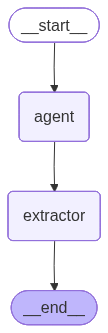

In [12]:
# Build the graph with both nodes
long_term_store = InMemoryStore()
short_term_memory = MemorySaver()

builder = StateGraph(MemoryAgentState)
builder.add_node("agent",     memory_agent_node)
builder.add_node("extractor", memory_extractor_node)

builder.add_edge(START,       "agent")
builder.add_edge("agent",     "extractor")
builder.add_edge("extractor", END)

memory_graph = builder.compile(
    checkpointer=short_term_memory,
    store=long_term_store
)

# Visualise
from IPython.display import Image, display
display(Image(memory_graph.get_graph().draw_mermaid_png()))

In [13]:
# Conversation 1 — introduce yourself
config_mem = {"configurable": {"thread_id": "session-1"}}

r1 = memory_graph.invoke(
    {"messages": [HumanMessage(content="Hi! I'm Rohan. I enjoy hiking and building AI tools.")],
     "user_id": "rohan"},
    config_mem
)
print("AI:", r1["messages"][-1].content)

  💾 Saved memory: Rohan
  💾 Saved memory: enjoys hiking
  💾 Saved memory: building AI tools
AI: Hi Rohan! It's great to meet you! Hiking and building AI tools sound like fantastic interests. Do you have any favorite hiking spots, or are you currently working on any exciting AI projects?


In [14]:
# Conversation 2 — new thread, but memories persist in the store
config_mem2 = {"configurable": {"thread_id": "session-2"}}

r2 = memory_graph.invoke(
    {"messages": [HumanMessage(content="What do you know about me?")],
     "user_id": "rohan"},
    config_mem2
)
print("AI:", r2["messages"][-1].content)

# Show stored memories
print("\n📋 Long-term memories:")
for m in long_term_store.search(("user:rohan", "memories")):
    print(f"  {m.key}: {m.value}")

AI: I know that your name is Rohan, and you enjoy hiking as well as building AI tools. If there's anything else you'd like to share about your interests or goals, feel free to let me know!

📋 Long-term memories:
  mem-d33d5cb0: {'fact': 'Rohan', 'created': '2026-03-01T23:08:08.379291'}
  mem-feb3d864: {'fact': 'enjoys hiking', 'created': '2026-03-01T23:08:08.379606'}
  mem-ad1c4acb: {'fact': 'building AI tools', 'created': '2026-03-01T23:08:08.379656'}


---

## 5️⃣ Combining Persistent Checkpoints + Long-Term Store

The most powerful setup combines both:
- `SqliteSaver` — persists full conversation history per thread (survives restarts)
- `InMemoryStore` — holds extracted facts (shared across threads)

In production you'd replace `InMemoryStore` with a database-backed store (Redis, Postgres, etc.).

In [15]:
COMBINED_DB = "combined_memory.db"

combined_store = InMemoryStore()  # in prod: swap for a DB-backed store

with SqliteSaver.from_conn_string(COMBINED_DB) as sqlite_cp:
    combined_graph = builder.compile(
        checkpointer=sqlite_cp,
        store=combined_store
    )

    cfg = {"configurable": {"thread_id": "full-memory-thread"}}

    turns = [
        "I'm Rohan, a software engineer. My favourite language is Python.",
        "I've been learning LangGraph for a week now.",
        "Summarise everything you know about me.",
    ]

    for turn in turns:
        result = combined_graph.invoke(
            {"messages": [HumanMessage(content=turn)], "user_id": "rohan"},
            cfg
        )
        print(f"\n🧑 You: {turn}")
        print(f"🤖 AI: {result['messages'][-1].content}")

print(f"\n💾 Conversations saved to {COMBINED_DB}")

  💾 Saved memory: Rohan
  💾 Saved memory: software engineer
  💾 Saved memory: favourite language is Python

🧑 You: I'm Rohan, a software engineer. My favourite language is Python.
🤖 AI: Nice to meet you, Rohan! Python is a fantastic language, known for its versatility and ease of use. Do you have any specific projects you're currently working on, or are there any areas in Python that you're particularly interested in exploring?

🧑 You: I've been learning LangGraph for a week now.
🤖 AI: That's great to hear, Rohan! LangGraph sounds like an interesting tool. How are you finding it so far? Are you working on any specific projects or applications using LangGraph?

🧑 You: Summarise everything you know about me.
🤖 AI: Sure! Here's what I know about you, Rohan:

- Your name is Rohan.
- You are a software engineer.
- Your favorite programming language is Python.
- You've been learning LangGraph for about a week.

If there's anything else you'd like to share or update, feel free to let me know!

---

## 6️⃣ Memory Management — CRUD on the Store

Sometimes you need to programmatically manage memories (e.g., a "forget me" feature or an admin tool).

In [16]:
def list_memories(store: BaseStore, user_id: str):
    ns = (f"user:{user_id}", "memories")
    items = store.search(ns)
    if not items:
        print("No memories stored.")
        return
    print(f"Memories for '{user_id}':")
    for item in items:
        print(f"  [{item.key}] {item.value}")

def forget_memory(store: BaseStore, user_id: str, key: str):
    ns = (f"user:{user_id}", "memories")
    store.delete(ns, key)
    print(f"🗑️  Deleted memory '{key}'")

def add_memory(store: BaseStore, user_id: str, fact: str):
    ns = (f"user:{user_id}", "memories")
    key = f"mem-{uuid.uuid4().hex[:8]}"
    store.put(ns, key, {"fact": fact, "created": datetime.now().isoformat()})
    print(f"✅ Added memory [{key}]: {fact}")
    return key

# Demo
print("=== Before ===")
list_memories(combined_store, "rohan")

new_key = add_memory(combined_store, "rohan", "dreams of running a marathon")

print("\n=== After adding ===")
list_memories(combined_store, "rohan")

=== Before ===
Memories for 'rohan':
  [mem-8d17624b] {'fact': 'Rohan', 'created': '2026-03-01T23:09:55.589442'}
  [mem-b9026b2f] {'fact': 'software engineer', 'created': '2026-03-01T23:09:55.589555'}
  [mem-e2695179] {'fact': 'favourite language is Python', 'created': '2026-03-01T23:09:55.589578'}
✅ Added memory [mem-06a60a7a]: dreams of running a marathon

=== After adding ===
Memories for 'rohan':
  [mem-8d17624b] {'fact': 'Rohan', 'created': '2026-03-01T23:09:55.589442'}
  [mem-b9026b2f] {'fact': 'software engineer', 'created': '2026-03-01T23:09:55.589555'}
  [mem-e2695179] {'fact': 'favourite language is Python', 'created': '2026-03-01T23:09:55.589578'}
  [mem-06a60a7a] {'fact': 'dreams of running a marathon', 'created': '2026-03-01T23:10:48.443744'}


In [17]:
# Forget a specific memory
forget_memory(combined_store, "rohan", new_key)

print("\n=== After forgetting ===")
list_memories(combined_store, "rohan")

🗑️  Deleted memory 'mem-06a60a7a'

=== After forgetting ===
Memories for 'rohan':
  [mem-8d17624b] {'fact': 'Rohan', 'created': '2026-03-01T23:09:55.589442'}
  [mem-b9026b2f] {'fact': 'software engineer', 'created': '2026-03-01T23:09:55.589555'}
  [mem-e2695179] {'fact': 'favourite language is Python', 'created': '2026-03-01T23:09:55.589578'}


---

## 7️⃣ Conversation Summarisation — Managing Context Window

Long conversations accumulate many messages, eventually hitting the LLM's context window limit. A common pattern is to **summarise** older messages and keep the summary as a single `SystemMessage`.

```
[msg1, msg2, msg3, msg4, msg5, msg6]   ← all messages, growing forever
        ↓  after summarisation
[SystemMessage("Summary of msgs 1-4"), msg5, msg6]  ← compact
```

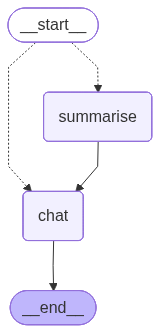

✅ Summary graph ready


In [18]:
SUMMARY_THRESHOLD = 6  # summarise when we have more than this many messages

class SummaryState(TypedDict):
    messages: Annotated[list, add_messages]
    summary: str   # running summary of old messages


def summarise_if_needed(state: SummaryState) -> SummaryState:
    """Summarise older messages when the list exceeds the threshold."""
    messages = state["messages"]

    if len(messages) <= SUMMARY_THRESHOLD:
        return {}  # nothing to do

    # Keep the last 2 messages, summarise the rest
    to_summarise = messages[:-2]
    recent = messages[-2:]

    existing_summary = state.get("summary", "")
    summary_prompt = (
        f"Existing summary (if any):\n{existing_summary}\n\n"
        f"New messages to add to summary:\n"
        + "\n".join(f"{type(m).__name__}: {m.content}" for m in to_summarise)
        + "\n\nWrite a concise updated summary capturing key facts and decisions."
    )
    new_summary = llm.invoke([HumanMessage(content=summary_prompt)]).content

    print(f"📝 Summarised {len(to_summarise)} messages → kept {len(recent)}")
    return {"messages": recent, "summary": new_summary}


def summary_chat_node(state: SummaryState) -> SummaryState:
    """Chat node that prepends the running summary as a system message."""
    summary = state.get("summary", "")
    system_msgs = []
    if summary:
        system_msgs = [SystemMessage(content=f"Conversation summary so far:\n{summary}")]

    response = llm.invoke(system_msgs + state["messages"])
    return {"messages": [response]}


def should_summarise(state: SummaryState) -> str:
    return "summarise" if len(state["messages"]) > SUMMARY_THRESHOLD else "chat"


# Build graph
summary_builder = StateGraph(SummaryState)
summary_builder.add_node("chat",      summary_chat_node)
summary_builder.add_node("summarise", summarise_if_needed)

summary_builder.add_conditional_edges(START, should_summarise, {"chat": "chat", "summarise": "summarise"})
summary_builder.add_edge("summarise", "chat")
summary_builder.add_edge("chat", END)

summary_graph = summary_builder.compile(checkpointer=MemorySaver())

display(Image(summary_graph.get_graph().draw_mermaid_png()))
print("✅ Summary graph ready")

In [ ]:
cfg_sum = {"configurable": {"thread_id": "summary-demo"}}

# Send 8 messages to trigger summarisation
conversation = [
    "Hi, I'm starting to learn LangGraph.",
    "I completed Day 1 yesterday — basics and LangSmith.",
    "Day 2 was about chains and memory.",
    "Day 3 covered vector embeddings and ChromaDB.",
    "Day 4 was advanced RAG with citations.",
    "Day 5 introduced ReAct agents.",
    "Day 6 was the intro to LangGraph state machines.",
    "What have I learned so far?",  # should use summarised context
]

for msg in conversation:
    # Do NOT pass "summary" after the first message — LangGraph loads it from the checkpoint.
    # Passing summary="" on every invoke would wipe the running summary each turn.
    result = summary_graph.invoke(
        {"messages": [HumanMessage(content=msg)]},
        cfg_sum
    )

print("\n🤖 Final AI response:")
print(result["messages"][-1].content)

print("\n📋 Running summary:")
print(result.get("summary", "(none yet)"))

📝 Summarised 5 messages → kept 2
📝 Summarised 7 messages → kept 2
📝 Summarised 9 messages → kept 2
📝 Summarised 11 messages → kept 2
📝 Summarised 13 messages → kept 2

🤖 Final AI response:
Here's a summary of what you've learned so far in your LangGraph learning journey:

### LangGraph Learning Journey Summary

1. **Day 1: Basics and LangSmith**
   - Introduced foundational concepts of LangGraph and LangSmith for effective platform usage.

2. **Day 2: Chains and Memory**
   - **Chains**: Learned how to link multiple operations for modular and complex workflows.
   - **Memory**: Explored enabling applications to retain user context and preferences for personalized interactions.

3. **Day 3: Vector Embeddings and ChromaDB**
   - **Vector Embeddings**: Understood how to represent text as numerical vectors for measuring similarity and enhancing NLP tasks.
   - **ChromaDB**: Discovered a database solution for storing and retrieving vector data, facilitating similarity searches.

4. **Day 4:

---

## 8️⃣ Putting It All Together — Full Memory-Aware Personal Assistant

Let's build the final version: a personal assistant with:
- ✅ **SqliteSaver** — persistent conversation history per thread
- ✅ **InMemoryStore** — long-term semantic facts across threads
- ✅ **Summarisation** — manages context window growth
- ✅ **Multi-user support** — isolated by `user_id`

In [28]:
ASSISTANT_DB  = "assistant_memory.db"
SUMMARY_LIMIT = 8

class AssistantState(TypedDict):
    messages: Annotated[list, add_messages]
    user_id:  str
    summary:  str


def _parse_json_facts(raw_content: str) -> list:
    """Parse a JSON array from LLM output, stripping markdown fences."""
    raw = raw_content.strip()
    if raw.startswith("```"):
        lines = raw.splitlines()
        raw = "\n".join(lines[1:-1]) if lines[-1].strip() == "```" else "\n".join(lines[1:])
    return json.loads(raw.strip())


def assistant_chat(state: AssistantState, config: RunnableConfig, store: BaseStore):
    user_id  = state["user_id"]
    ns       = (f"user:{user_id}", "memories")
    memories = store.search(ns)
    mem_text = "\n".join(f"- {m.value['fact']}" for m in memories) if memories else "None yet."
    summary  = state.get("summary", "")

    system_parts = ["You are a helpful personal assistant."]
    if summary:
        system_parts.append(f"\nConversation summary:\n{summary}")
    system_parts.append(f"\nKnown facts about the user:\n{mem_text}")

    response = llm.invoke([SystemMessage(content="\n".join(system_parts))] + state["messages"])
    return {"messages": [response]}


def assistant_extract(state: AssistantState, config: RunnableConfig, store: BaseStore):
    user_id = state["user_id"]
    ns      = (f"user:{user_id}", "memories")
    last_human = next((m for m in reversed(state["messages"]) if isinstance(m, HumanMessage)), None)
    if not last_human:
        return {}
    result = llm.invoke([
        SystemMessage(content=(
            "Extract ALL useful personal facts from the user message below. "
            "Include: name, profession, hobbies, preferences, goals, "
            "technologies they are learning or using, projects they are working on, "
            "and any other information that would help personalise future responses. "
            "Return a JSON array of concise fact strings (e.g. [\"learning LangGraph\", \"software engineer\"]). "
            "Return [] only if the message contains zero personal information. "
            "Return ONLY the JSON array, no other text."
        )),
        HumanMessage(content=last_human.content)
    ])
    try:
        facts = _parse_json_facts(result.content)
        for fact in facts:
            store.put(ns, f"mem-{uuid.uuid4().hex[:8]}",
                      {"fact": fact, "created": datetime.now().isoformat()})
            print(f"  💾 Saved: {fact}")
        if not facts:
            print("  ℹ️  No new facts extracted")
    except Exception as e:
        print(f"  ⚠️  Extraction error: {e} | raw: {result.content[:120]!r}")
    return {}


def assistant_summarise(state: AssistantState) -> AssistantState:
    messages = state["messages"]
    if len(messages) <= SUMMARY_LIMIT:
        return {}
    old, recent = messages[:-2], messages[-2:]
    existing = state.get("summary", "")
    prompt = (f"Existing summary:\n{existing}\n\nNew messages:\n"
              + "\n".join(f"{type(m).__name__}: {m.content}" for m in old)
              + "\n\nWrite a concise updated summary.")
    new_summary = llm.invoke([HumanMessage(content=prompt)]).content
    return {"messages": recent, "summary": new_summary}


def route_start(state: AssistantState) -> str:
    return "summarise" if len(state["messages"]) > SUMMARY_LIMIT else "chat"


# Build
asst_builder = StateGraph(AssistantState)
asst_builder.add_node("chat",      assistant_chat)
asst_builder.add_node("extract",   assistant_extract)
asst_builder.add_node("summarise", assistant_summarise)

asst_builder.add_conditional_edges(START, route_start,
    {"chat": "chat", "summarise": "summarise"})
asst_builder.add_edge("summarise", "chat")
asst_builder.add_edge("chat",      "extract")
asst_builder.add_edge("extract",   END)

full_store = InMemoryStore()

print("✅ Assistant nodes defined — ready to compile")

✅ Assistant nodes defined — ready to compile


🗑️  Cleared stale assistant_memory.db


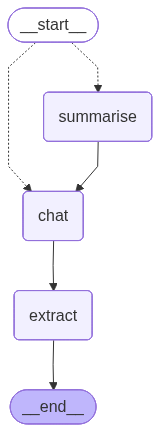


🤖 Personal Assistant — Demo Conversation
  💾 Saved: Rohan
  💾 Saved: software engineer
  💾 Saved: loves hiking

[session-A] 🧑 Hi! I'm Rohan, a software engineer who loves hiking.
[session-A] 🤖 Hi Rohan! It’s great to meet you! As a software engineer who loves hiking, you must have a nice balance between tech and nature. Do you have any favorite hiking spots or trails? Or are there any projects you're currently working on that you're excited about?
  💾 Saved: learning LangGraph
  💾 Saved: building AI agents

[session-A] 🧑 I'm currently learning LangGraph for building AI agents.
[session-A] 🤖 That sounds exciting! LangGraph is a powerful tool for building AI agents. What specific projects or applications are you thinking of creating with it? And have you come across any challenges while learning it?
  ℹ️  No new facts extracted

[session-B] 🧑 Hello again! What do you know about me so far?
[session-B] 🤖 Hello, Rohan! Here's what I know about you:

- You are a software engineer.
- You lov

In [29]:
import os

# Remove stale DB from previous runs so we start fresh
if os.path.exists(ASSISTANT_DB):
    os.remove(ASSISTANT_DB)
    print(f"🗑️  Cleared stale {ASSISTANT_DB}")

with SqliteSaver.from_conn_string(ASSISTANT_DB) as asst_cp:
    assistant = asst_builder.compile(checkpointer=asst_cp, store=full_store)

    display(Image(assistant.get_graph().draw_mermaid_png()))

    print("\n🤖 Personal Assistant — Demo Conversation")
    print("=" * 50)

    demo_turns = [
        ("session-A", "Hi! I'm Rohan, a software engineer who loves hiking."),
        ("session-A", "I'm currently learning LangGraph for building AI agents."),
        ("session-B", "Hello again! What do you know about me so far?"),  # new thread, same user
        ("session-B", "What would you recommend I work on next given what I'm learning?"),
    ]

    for thread_id, user_msg in demo_turns:
        cfg = {"configurable": {"thread_id": thread_id}}
        res = assistant.invoke(
            {"messages": [HumanMessage(content=user_msg)], "user_id": "rohan"},
            cfg
        )
        print(f"\n[{thread_id}] 🧑 {user_msg}")
        print(f"[{thread_id}] 🤖 {res['messages'][-1].content}")

print(f"\n💾 Saved to {ASSISTANT_DB}")

In [27]:
# Show all long-term memories extracted across both sessions
print("📋 Long-term memories for 'rohan':")
list_memories(full_store, "rohan")

📋 Long-term memories for 'rohan':
Memories for 'rohan':
  [mem-65fa8379] {'fact': 'Rohan', 'created': '2026-03-01T23:31:53.130363'}
  [mem-bfea7d15] {'fact': 'software engineer', 'created': '2026-03-01T23:31:53.130747'}
  [mem-2b61e358] {'fact': 'loves hiking', 'created': '2026-03-01T23:31:53.130973'}


---

## 📊 Summary — Memory System Comparison

| Approach | Scope | Persistence | Best For |
|---|---|---|---|
| `add_messages` | In-prompt | RAM only | Simple single-turn chat |
| `MemorySaver` | Per thread | RAM (session) | Dev / testing |
| `SqliteSaver` | Per thread | SQLite file | Single-server production |
| `InMemoryStore` | Cross-thread | RAM (session) | Semantic facts during dev |
| DB-backed Store | Cross-thread | Persistent DB | Full production |
| Summarisation | In-prompt | Via checkpointer | Long conversations |

## ✅ Key Takeaways

1. **`MemorySaver`** is great for development but memory dies with the process
2. **`SqliteSaver`** gives you free persistence — drop-in replacement for `MemorySaver`
3. The **Store** is separate from the checkpointer — use it for facts that transcend individual conversations
4. **Summarisation** is essential for production chatbots to avoid context-window overflow
5. **`user_id` in state + namespaced store** = clean multi-user memory isolation

## 🔜 Day 9 Preview — Production Patterns

- Wrap everything in a **FastAPI** REST API
- Add request authentication per user
- Swap `InMemoryStore` for **Redis** or **PostgreSQL**
- Containerise with **Docker**
- Add structured logging and health checks